In [1]:
import pandas as pd
import numpy as np

path = r"C:\Users\negia\trip_plan\dwell_model\adjusted_dwell_model_pipeline\data\adjusted_google_osm_pois.csv"

df = pd.read_csv(path)

print(df.shape)
display(df.head())
display(df.dtypes)

(3724, 56)


,poi_id,google_place_id,source_global_venue_ids,poi_name,google_name,dataset_city,venue_city,venue_country,latitude,longitude,...,osm_safety_proxy_count_400m,osm_safety_proxy_count_600m,osm_safety_proxy_nearest_m,osm_security_proxy_count_400m,osm_security_proxy_count_600m,osm_security_proxy_nearest_m,parking_availability,public_transport_availability,osm_safety_proxy,osm_security_proxy
0,ChIJ-4c-i2DmaC4RJr9NbGteNxI,ChIJ-4c-i2DmaC4RJr9NbGteNxI,bandung::921,Solaria,Solaria • PVJ,bandung,Bandung,ID,-6.889492,107.595838,...,3,4,148.859702,2,2,148.859702,high,high,high,high
1,ChIJ-7qJXVzmaC4RcXKxLUs5FV0,ChIJ-7qJXVzmaC4RcXKxLUs5FV0,bandung::454,Masjid Raya Cipaganti,Masjid Besar Cipaganti,bandung,Bandung,ID,-6.894784,107.602319,...,4,11,289.559976,0,2,498.896108,high,high,high,medium
2,ChIJ-QQOJyLmaC4R8lGXvLdi16o,ChIJ-QQOJyLmaC4R8lGXvLdi16o,bandung::2685,Lomie Ayam 61,Lomie 61,bandung,Bandung,ID,-6.923449,107.599807,...,21,38,137.456929,2,6,137.557827,medium,high,high,high
3,ChIJ-WweZuroaC4R7TRJ2qxwgp4,ChIJ-WweZuroaC4R7TRJ2qxwgp4,bandung::5243,Sambel Hejo Singgasana,SHSD Sambel Hejo Sambel Dadak Mekar Wangi,bandung,Bandung,ID,-6.952466,107.599012,...,11,19,254.570278,0,0,710.072525,high,low,high,low
4,ChIJ-XlhLLXnaC4Ruy9t4edIAEs,ChIJ-XlhLLXnaC4Ruy9t4edIAEs,bandung::711,Masjid Istiqomah,Istiqamah Mosque,bandung,Bandung,ID,-6.904838,107.621435,...,20,43,72.737795,25,52,33.092119,high,high,high,high


poi_id                                     str
google_place_id                            str
source_global_venue_ids                    str
poi_name                                   str
google_name                                str
dataset_city                               str
venue_city                                 str
venue_country                              str
latitude                               float64
longitude                              float64
category_group                             str
venue_category                             str
obs_count                                int64
median_adjusted_dwell_minutes          float64
mean_adjusted_dwell_minutes            float64
std_adjusted_dwell_minutes             float64
median_raw_gap_minutes                 float64
median_estimated_travel_time_min       float64
median_distance_to_next_poi_km         float64
near_duplicate_transition_rate         float64
google_primary_type                        str
google_types 

In [2]:
target = "median_adjusted_dwell_minutes"

display(df[target].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

print("Missing target:", df[target].isna().sum())
print("Min:", df[target].min())
print("Max:", df[target].max())

count    3724.000000
mean       76.857277
std        31.236201
min        12.161777
1%         24.768454
5%         35.517230
25%        54.648639
50%        71.328420
75%        94.925864
95%       135.760345
99%       168.696196
max       234.748130
Name: median_adjusted_dwell_minutes, dtype: float64

Missing target: 0
Min: 12.161776961164058
Max: 234.74812964148416


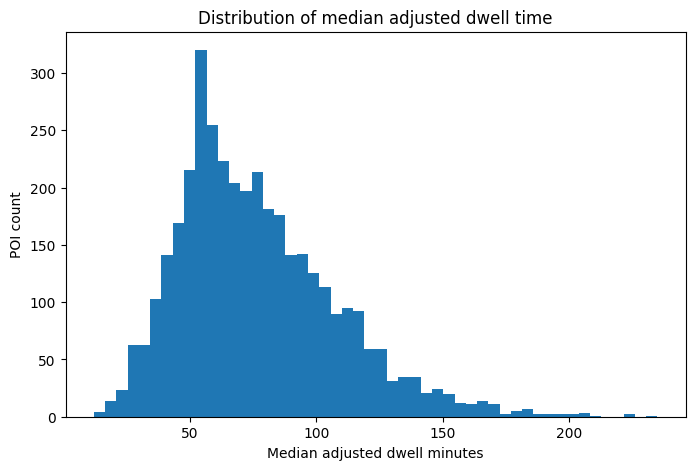

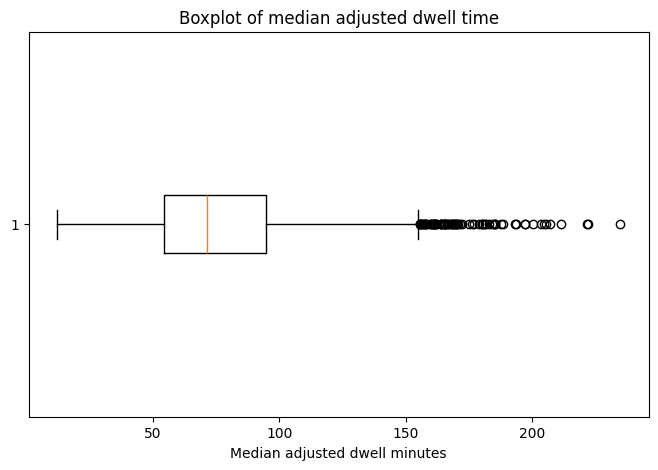

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df[target].dropna(), bins=50)
plt.xlabel("Median adjusted dwell minutes")
plt.ylabel("POI count")
plt.title("Distribution of median adjusted dwell time")
plt.show()

plt.figure(figsize=(8, 5))
plt.boxplot(df[target].dropna(), vert=False)
plt.xlabel("Median adjusted dwell minutes")
plt.title("Boxplot of median adjusted dwell time")
plt.show()

count    3724.000000
mean       33.650913
std       135.602689
min         5.000000
1%          5.000000
5%          5.000000
25%         6.000000
50%         9.000000
75%        18.000000
95%       106.000000
99%       538.770000
max      3235.000000
Name: obs_count, dtype: float64

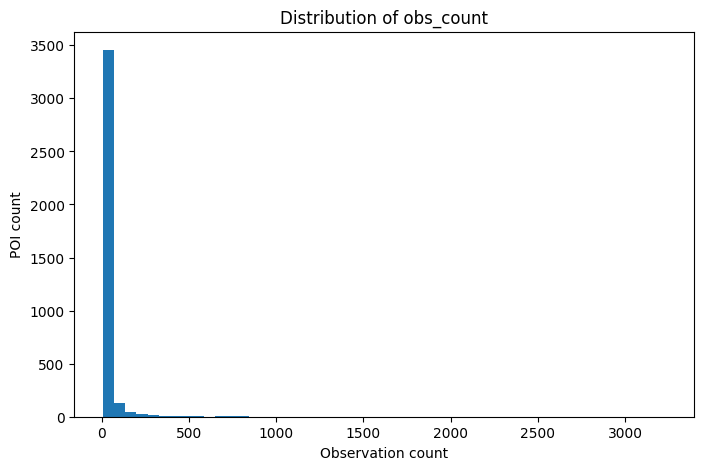

,count,mean,median,std
obs_count,,,,
"(0, 5]",681,77.823479,71.615886,37.281045
"(5, 10]",1437,79.055346,74.403843,32.194723
"(10, 20]",810,77.655019,74.140476,29.037964
"(20, 50]",426,73.560954,68.759027,27.341911
"(50, 100]",174,71.538049,65.459483,23.864855
"(100, 500]",154,66.726117,63.391680,19.190609
"(500, 10000]",42,63.219116,63.588479,8.537722


In [4]:
display(df["obs_count"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

plt.figure(figsize=(8, 5))
plt.hist(df["obs_count"].dropna(), bins=50)
plt.xlabel("Observation count")
plt.ylabel("POI count")
plt.title("Distribution of obs_count")
plt.show()

display(
    df.groupby(pd.cut(df["obs_count"], bins=[0,5,10,20,50,100,500,10000]))[target]
      .agg(["count", "mean", "median", "std"])
)

In [5]:
display(
    df.groupby("category_group")[target]
      .agg(["count", "mean", "median", "std"])
      .sort_values("median", ascending=False)
)

,count,mean,median,std
category_group,,,,
tourism_attraction,836,92.549919,85.878081,37.681939
food_leisure,1938,76.392890,73.991415,25.106912
shopping,950,63.995103,57.022930,30.146045


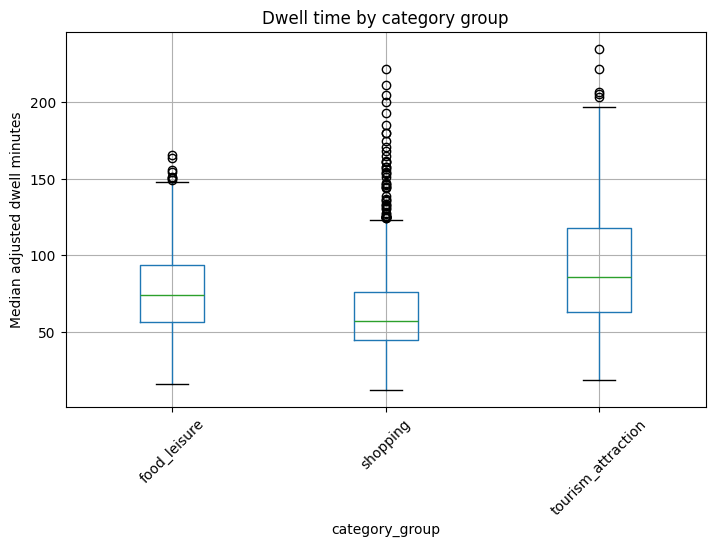

In [6]:
df.boxplot(column=target, by="category_group", figsize=(8, 5), rot=45)
plt.suptitle("")
plt.title("Dwell time by category group")
plt.ylabel("Median adjusted dwell minutes")
plt.show()

count    3724.000000
mean        4.279901
std         0.420556
min         1.000000
25%         4.100000
50%         4.400000
75%         4.500000
max         5.000000
Name: google_rating_filled, dtype: float64

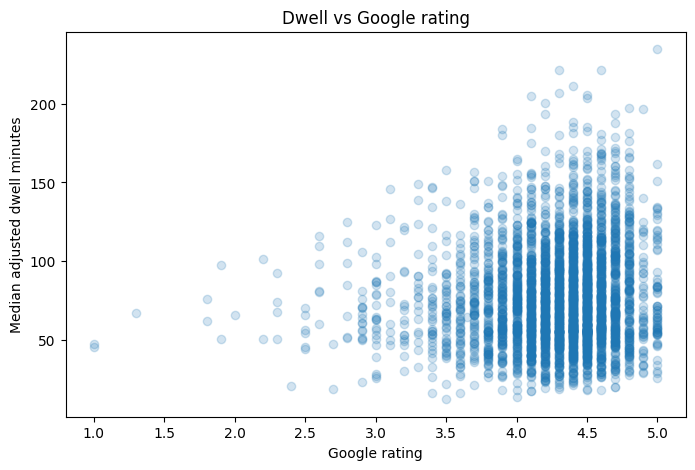

                               google_rating_filled  \
google_rating_filled                       1.000000   
median_adjusted_dwell_minutes              0.092318   

                               median_adjusted_dwell_minutes  
google_rating_filled                                0.092318  
median_adjusted_dwell_minutes                       1.000000  


In [7]:
display(df["google_rating_filled"].describe())

plt.figure(figsize=(8, 5))
plt.scatter(df["google_rating_filled"], df[target], alpha=0.2)
plt.xlabel("Google rating")
plt.ylabel("Median adjusted dwell minutes")
plt.title("Dwell vs Google rating")
plt.show()

print(df[["google_rating_filled", target]].corr())

count    3724.000000
mean        6.681656
std         2.079574
min         0.693147
25%         5.406048
50%         6.944569
75%         8.118654
max        11.010411
Name: log_google_user_rating_count_capped, dtype: float64

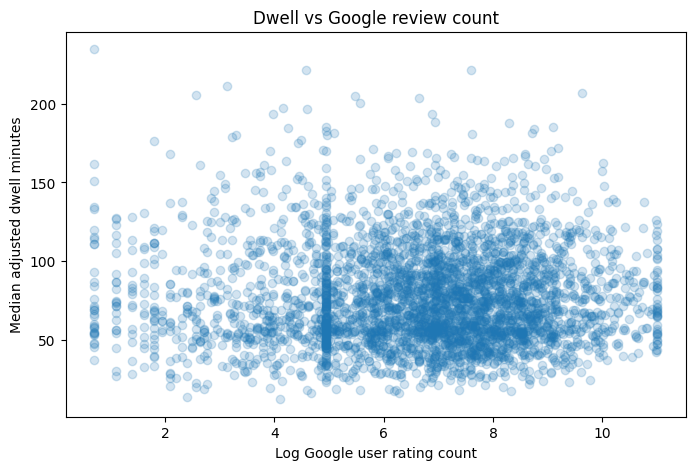

                                     log_google_user_rating_count_capped  \
log_google_user_rating_count_capped                             1.000000   
median_adjusted_dwell_minutes                                  -0.001829   

                                     median_adjusted_dwell_minutes  
log_google_user_rating_count_capped                      -0.001829  
median_adjusted_dwell_minutes                             1.000000  


In [8]:
review_col = "log_google_user_rating_count_capped"

display(df[review_col].describe())

plt.figure(figsize=(8, 5))
plt.scatter(df[review_col], df[target], alpha=0.2)
plt.xlabel("Log Google user rating count")
plt.ylabel("Median adjusted dwell minutes")
plt.title("Dwell vs Google review count")
plt.show()

print(df[[review_col, target]].corr())

In [9]:
osm_level_cols = [
    "parking_availability",
    "public_transport_availability",
    "osm_safety_proxy",
    "osm_security_proxy",
]

for col in osm_level_cols:
    print("\n", col)
    display(df[col].value_counts(dropna=False))
    display(
        df.groupby(col)[target]
          .agg(["count", "mean", "median", "std"])
          .sort_values("median", ascending=False)
    )


 parking_availability


parking_availability
high      3357
medium     203
low        164
Name: count, dtype: int64

,count,mean,median,std
parking_availability,,,,
low,164,79.740254,75.256211,30.928736
medium,203,81.507867,74.522268,35.540913
high,3357,76.435210,71.194093,30.951822



 public_transport_availability


public_transport_availability
high      3531
low        118
medium      75
Name: count, dtype: int64

...

osm_safety_proxy
high      3181
low        272
medium     271
Name: count, dtype: int64

,count,mean,median,std
osm_safety_proxy,,,,
medium,271,79.089618,74.625731,31.564882
low,272,74.833454,71.676506,29.413028
high,3181,76.840149,71.063392,31.356166



 osm_security_proxy


osm_security_proxy
high      2200
low        996
medium     528
Name: count, dtype: int64

,count,mean,median,std
osm_security_proxy,,,,
medium,528,80.417538,75.643258,32.755944
high,2200,76.116254,70.689466,30.789714
low,996,76.606707,70.439441,31.294629


In [10]:
cols_to_check = [
    target,
    "category_group",
    "google_rating",
    "google_rating_filled",
    "google_user_rating_count",
    "log_google_user_rating_count_capped",
    "has_google_rating",
    "has_google_user_rating_count",
    "parking_availability",
    "public_transport_availability",
    "osm_safety_proxy",
    "osm_security_proxy",
    "dataset_city",
    "obs_count",
]

missing = df[cols_to_check].isna().sum().sort_values(ascending=False)
display(missing)
display((missing / len(df)).sort_values(ascending=False))

google_user_rating_count               227
google_rating                          227
category_group                           0
median_adjusted_dwell_minutes            0
google_rating_filled                     0
log_google_user_rating_count_capped      0
has_google_rating                        0
has_google_user_rating_count             0
parking_availability                     0
public_transport_availability            0
osm_safety_proxy                         0
osm_security_proxy                       0
dataset_city                             0
obs_count                                0
dtype: int64

google_user_rating_count               0.060956
google_rating                          0.060956
category_group                         0.000000
median_adjusted_dwell_minutes          0.000000
google_rating_filled                   0.000000
log_google_user_rating_count_capped    0.000000
has_google_rating                      0.000000
has_google_user_rating_count           0.000000
parking_availability                   0.000000
public_transport_availability          0.000000
osm_safety_proxy                       0.000000
osm_security_proxy                     0.000000
dataset_city                           0.000000
obs_count                              0.000000
dtype: float64

In [11]:
main_features = [
    "category_group",
    "google_rating_filled",
    "log_google_user_rating_count_capped",
    "parking_availability",
    "public_transport_availability",
    "osm_safety_proxy",
    "osm_security_proxy",
    "dataset_city",
]

for col in main_features:
    print("\n---", col, "---")
    if df[col].dtype == "object":
        display(df[col].value_counts(dropna=False).head(30))
    else:
        display(df[col].describe())


--- category_group ---


count             3724
unique               3
top       food_leisure
freq              1938
Name: category_group, dtype: object


--- google_rating_filled ---


count    3724.000000
mean        4.279901
std         0.420556
min         1.000000
25%         4.100000
50%         4.400000
75%         4.500000
max         5.000000
Name: google_rating_filled, dtype: float64


--- log_google_user_rating_count_capped ---


...

count     3724
unique       3
top       high
freq      3181
Name: osm_safety_proxy, dtype: object


--- osm_security_proxy ---


count     3724
unique       3
top       high
freq      2200
Name: osm_security_proxy, dtype: object


--- dataset_city ---


count         3724
unique          14
top       new_york
freq           735
Name: dataset_city, dtype: object

In [12]:
q1 = df[target].quantile(0.25)
q3 = df[target].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = df[(df[target] < lower) | (df[target] > upper)].copy()

print("Lower bound:", lower)
print("Upper bound:", upper)
print("Outliers:", len(outliers))

display(
    outliers[
        [
            "poi_name",
            "dataset_city",
            "category_group",
            "obs_count",
            target,
            "median_raw_gap_minutes",
            "median_estimated_travel_time_min",
            "median_distance_to_next_poi_km",
        ]
    ].sort_values(target, ascending=False).head(30)
)

Lower bound: -5.767198950096116
Upper bound: 155.34170205555827
Outliers: 76


,poi_name,dataset_city,category_group,obs_count,median_adjusted_dwell_minutes,median_raw_gap_minutes,median_estimated_travel_time_min,median_distance_to_next_poi_km
3502,Acabit Tecnologia,sao_paulo,tourism_attraction,21,234.748130,240.0,5.251870,0.393890
3500,Portal da Leitura,sao_paulo,shopping,5,221.849567,223.0,1.150433,0.086283
3231,Prodata Mobility Assistência Técnica,sao_paulo,tourism_attraction,10,221.630320,234.0,12.458853,3.737656
373,Akademi Denizcilik,istanbul,shopping,5,211.291205,217.0,5.708795,0.428160
1700,Marvel Stadium,melbourne,tourism_attraction,10,206.796757,213.0,6.322192,1.192233
3442,Argotechno,sao_paulo,tourism_attraction,24,205.511038,209.5,5.802708,0.435203
921,Lawson,jakarta,shopping,5,204.691557,206.0,3.125429,0.234407
2049,David Zwirner Gallery,new_york,tourism_attraction,5,203.509728,208.0,5.349008,1.347082
3538,Hortifruti Vila Olímpia,sao_paulo,shopping,5,200.301882,209.0,8.698118,0.652359
24,Masjid Miftahul Khair,bandung,tourism_attraction,7,197.131366,198.0,0.868634,0.065148
